# TP M2-1 — Les six bonus — équipe 02

Ce notebook est **séparé du TP principal** et traite les six propositions de la section 9 du PDF.
Les bonus 1 à 4 utilisent **BIDMC 02**. Le bonus 5 étudie **PPG-DaLiA S1** (autre jeu de données, démonstration sur un seul sujet). Le bonus 6 couvre **les 53 enregistrements BIDMC**.

Les sorties ci-dessous proviennent d'une exécution réelle. Aucun résultat synthétique n'est présenté comme une mesure réelle. Un petit signal synthétique est utilisé uniquement pour tester explicitement la limite du critère de régularité dans le bonus 4.

En local : ouvrir ce notebook avec Jupyter et exécuter toutes les cellules. Dans Colab : importer le notebook ; les cellules contiennent toutes les fonctions. Les données manquantes sont téléchargées depuis les sources officielles (le bonus DaLiA peut transférer environ 1,3 Go pour extraire S1). Les CSV et le fichier DaLiA brut sont exclus de Git.


In [1]:
from pathlib import Path
import os
import json
import warnings
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

depart = Path.cwd()
RACINE = next((p for p in (depart, *depart.parents)
               if (p / "analyses" / "m2_tp1").is_dir()), depart)
BONUS = RACINE / "analyses" / "m2_tp1" / "bonus"
BONUS.mkdir(parents=True, exist_ok=True)
RESULTATS = BONUS / "resultats"
RESULTATS.mkdir(exist_ok=True)
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True})
print("Résultats des bonus :", RESULTATS)


Résultats des bonus : E:\TP Iot\analyses\m2_tp1\bonus\resultats


In [2]:
"""Fonctions des bonus uniquement. Le code du TP principal reste inchangé."""
from pathlib import Path
import hashlib
import pickle
import struct
import urllib.request
import zlib
import numpy as np
import pandas as pd
from scipy import signal


def fc_fenetres(t_pics, instants, largeur=8.0):
    """Même convention d'intervalles que la boîte à outils du TP."""
    ibi = np.diff(t_pics)
    fin = t_pics[1:]
    fc = np.full(len(instants), np.nan)
    cv = np.full(len(instants), np.nan)
    for k, tc in enumerate(instants):
        dans = (fin >= tc - largeur / 2) & (fin < tc + largeur / 2)
        if dans.sum() >= 3:
            fc[k] = 60 / np.median(ibi[dans])
            cv[k] = np.std(ibi[dans]) / np.mean(ibi[dans])
    return fc, cv


def erreur(estimee, reference, masque=None):
    valide = np.isfinite(estimee) & np.isfinite(reference)
    if masque is not None:
        valide &= masque
    return float(np.mean(np.abs(estimee[valide] - reference[valide]))) if valide.any() else np.nan


def chaine(x, fs, instants, filtrer=True, causal=False):
    sos = signal.butter(4, [0.5, 5.0], fs=fs, btype='bandpass', output='sos')
    y = (signal.sosfilt(sos, x) if causal else signal.sosfiltfilt(sos, x)) if filtrer else x - np.mean(x)
    pics, _ = signal.find_peaks(y, distance=int(fs * 60 / 180), prominence=0.5 * np.std(y))
    fc, cv = fc_fenetres(pics / fs, instants)
    return y, pics, fc, cv


def qualite(fc, cv, seuil=0.15):
    return (cv < seuil) & (fc >= 40) & (fc <= 180)


def fc_fft(x, fs, instants):
    """FFT de 8 s, Hann, maximum entre 0,7 et 3 Hz, sans interpolation."""
    n = int(8 * fs)
    freq = np.fft.rfftfreq(n, 1 / fs)
    bande = (freq >= 0.7) & (freq <= 3)
    result = np.full(len(instants), np.nan)
    for k, tc in enumerate(instants):
        debut = round((tc - 4) * fs)
        if debut < 0 or debut + n > len(x):
            continue
        segment = x[debut:debut + n]
        puissance = np.abs(np.fft.rfft((segment - segment.mean()) * np.hanning(n))) ** 2
        result[k] = 60 * freq[bande][np.argmax(puissance[bande])]
    return result


def score_forme(x, pics, fs, instants):
    """Corrélation de chaque battement avec la forme moyenne de sa fenêtre.

    Extraits fixes de -0,20 à +0,30 s autour des pics, centrés et normalisés.
    Le score de la fenêtre est la corrélation minimale (critère conservateur).
    """
    avant, apres = round(0.20 * fs), round(0.30 * fs)
    bons = pics[(pics >= avant) & (pics + apres < len(x))]
    segments = np.array([x[p - avant:p + apres + 1] for p in bons])
    segments = segments - segments.mean(axis=1, keepdims=True)
    normes = np.linalg.norm(segments, axis=1, keepdims=True)
    segments = segments / np.maximum(normes, 1e-12)
    scores = np.full(len(instants), np.nan)
    for k, tc in enumerate(instants):
        dans = (bons / fs >= tc - 4) & (bons / fs < tc + 4)
        if dans.sum() < 3:
            continue
        moyenne = segments[dans].mean(axis=0)
        moyenne /= max(np.linalg.norm(moyenne), 1e-12)
        scores[k] = np.min(segments[dans] @ moyenne)
    return scores


def charger_bidmc(numero, racine, dossier_bonus):
    """Données officielles uniquement, sans repli synthétique, avec SHA-256."""
    dossier = Path(dossier_bonus) / 'data' / 'bidmc'
    dossier.mkdir(parents=True, exist_ok=True)
    manifest = dossier / 'SHA256SUMS.txt'
    if not manifest.exists():
        with urllib.request.urlopen('https://physionet.org/files/bidmc/1.0.0/SHA256SUMS.txt', timeout=90) as r:
            manifest.write_bytes(r.read())
    hashes = {line.split()[-1].split('/')[-1]: line.split()[0] for line in manifest.read_text().splitlines()}
    frames = []
    for suffixe in ['Signals', 'Numerics']:
        nom = f'bidmc_{numero:02d}_{suffixe}.csv'
        fichier = dossier / nom
        if not fichier.exists() and (Path(racine) / 'data' / nom).exists():
            fichier = Path(racine) / 'data' / nom
        if not fichier.exists():
            url = 'https://physionet.org/files/bidmc/1.0.0/bidmc_csv/' + nom
            with urllib.request.urlopen(url, timeout=180) as r:
                contenu = r.read()
            assert hashlib.sha256(contenu).hexdigest() == hashes[nom], nom
            fichier.write_bytes(contenu)
        assert hashlib.sha256(fichier.read_bytes()).hexdigest() == hashes[nom], nom
        df = pd.read_csv(fichier)
        df.columns = df.columns.str.strip()
        frames.append(df)
    return frames


def preparer_dalia(dossier_bonus):
    """Extrait le sujet S1 et la documentation du ZIP officiel, vérification CRC.

    Le serveur ne gère pas toujours HTTP Range. Lecture séquentielle jusqu'à S1,
    sans conserver les autres sujets (environ 1,3 Go transférés sur ce serveur).
    """
    dossier = Path(dossier_bonus) / 'data' / 'ppg_dalia'
    dossier.mkdir(parents=True, exist_ok=True)
    cible = dossier / 'S1.pkl'
    if not cible.exists():
        def lire(r, taille):
            morceaux = []
            while taille:
                b = r.read(min(taille, 1024 * 1024))
                if not b:
                    raise EOFError('Archive UCI incomplète')
                morceaux.append(b)
                taille -= len(b)
            return b''.join(morceaux)
        url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00495/data.zip'
        with urllib.request.urlopen(url, timeout=180) as r:
            while True:
                valeurs = struct.unpack('<4s5H3I2H', lire(r, 30))
                sig, _, flags, methode, _, _, crc, comp, taille, nomlen, extralen = valeurs
                if sig != b'PK\x03\x04' or flags & 8:
                    raise ValueError('Structure ZIP non prise en charge')
                nom = lire(r, nomlen).decode()
                lire(r, extralen)
                garder = nom.endswith('/S1.pkl') or nom.endswith('.pdf')
                print(nom, f'({comp / 1e6:.1f} Mo)', flush=True)
                morceaux = []
                restant = comp
                while restant:
                    bloc = lire(r, min(restant, 1024 * 1024))
                    restant -= len(bloc)
                    if garder:
                        morceaux.append(bloc)
                if garder:
                    contenu = b''.join(morceaux)
                    if methode == 8:
                        contenu = zlib.decompress(contenu, -15)
                    elif methode != 0:
                        raise ValueError('Compression ZIP non prise en charge')
                    assert len(contenu) == taille and zlib.crc32(contenu) == crc
                    (dossier / Path(nom).name).write_bytes(contenu)
                if nom.endswith('/S1.pkl'):
                    break

    class LectureRestreinte(pickle.Unpickler):
        def find_class(self, module, name):
            autorises = {('numpy.core.multiarray', '_reconstruct'),
                         ('numpy.core.multiarray', 'scalar'), ('numpy', 'ndarray'),
                         ('numpy', 'dtype'), ('_codecs', 'encode')}
            if (module, name) not in autorises:
                raise pickle.UnpicklingError(f'Classe inattendue : {module}.{name}')
            return super().find_class(module, name)
    with cible.open('rb') as f:
        d = LectureRestreinte(f, encoding='latin1').load()
    assert d['subject'] == 'S1'
    return (d['signal']['wrist']['BVP'].ravel(), d['signal']['wrist']['ACC'],
            np.asarray(d['label']), d['activity'].ravel())


In [3]:
FS = 125
def ajouter_artefact(x, t, debut, duree, gain, graine=0):
    """Simule un mouvement : bruit dans la bande 1-3 Hz (comme une marche) + sauts de ligne de base."""
    rng = np.random.default_rng(graine)
    y = x.copy()
    zone = (t >= debut) & (t < debut + duree)
    bruit = signal.sosfilt(signal.butter(2, [1, 3], btype="bandpass", fs=FS, output="sos"),
                           rng.normal(0, 1, zone.sum()))
    bruit = gain * np.std(x) * bruit / np.std(bruit)
    sauts = np.cumsum(rng.normal(0, 0.02, zone.sum())) * np.std(x)
    y[zone] += bruit + sauts
    return y

In [4]:
# Réglages identiques au TP principal.
sig, num = charger_bidmc(2, RACINE, BONUS)
x = sig["PLETH"].to_numpy(float)
t = np.arange(len(x)) / FS
reference = num[["Time [s]", "HR"]].dropna()
reference = reference[(reference["Time [s]"] >= 4) & (reference["Time [s]"] <= t[-1] - 4)]
tc = reference["Time [s]"].to_numpy(float)
hr = reference["HR"].to_numpy(float)
y, p, fc, cv = chaine(x, FS, tc)
x_art = ajouter_artefact(x, t, 200, 40, 3)
y_art, p_art, fc_art, cv_art = chaine(x_art, FS, tc)
zone = (tc >= 200) & (tc < 240)
assert len(x) == 60001 and np.isclose(erreur(fc, hr), 0.7987289230092033)
print(f"BIDMC 02 : {len(x)} mesures, MAE de référence du TP = {erreur(fc, hr):.3f} bpm")


BIDMC 02 : 60001 mesures, MAE de référence du TP = 0.799 bpm


## Bonus 1 — Comparer à PULSE, puis comparer les deux méthodes à HR

`HR` est la FC du moniteur dérivée de l'ECG ; `PULSE` est son estimation issue du PPG (documentation PhysioNet). On compare l'algorithme à `PULSE`, puis **algorithme et PULSE à la même référence HR**, aux mêmes instants valides. Cela évite de comparer des erreurs calculées sur des secondes différentes.


,Comparaison,MAE (bpm),Secondes communes
0,Algorithme / HR,0.799,473
1,PULSE / HR,1.218,473
2,Algorithme / PULSE,1.742,473


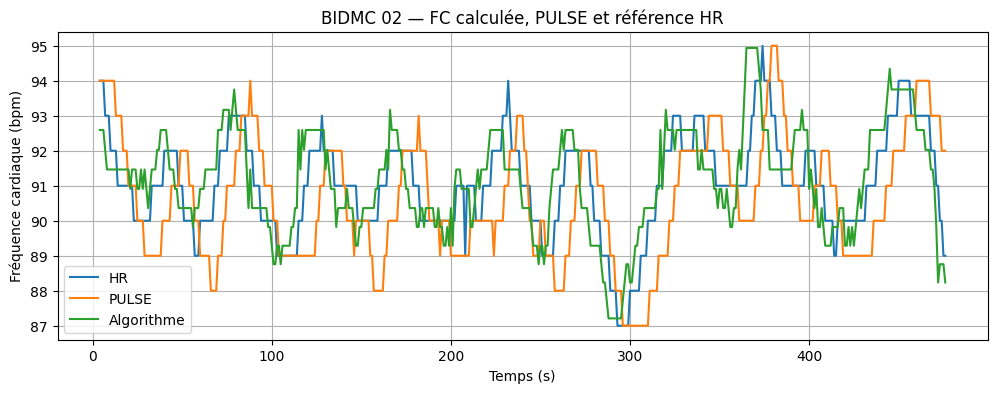

**Conclusion.** Notre MAE par rapport à HR est **0.799 bpm**, contre **1.218 bpm** pour PULSE : elle est **plus faible** sur cet enregistrement. L'écart de notre méthode à PULSE vaut 1.742 bpm. Cela ne démontre pas une supériorité générale : un seul patient et la référence fournie par le moniteur sont utilisés.

In [5]:
comparaison = pd.DataFrame({"Time [s]": tc, "Algorithme": fc}).merge(
    num[["Time [s]", "HR", "PULSE"]], on="Time [s]", how="inner").dropna()
e_algo_hr = erreur(comparaison.Algorithme.to_numpy(), comparaison.HR.to_numpy())
e_pulse_hr = erreur(comparaison.PULSE.to_numpy(), comparaison.HR.to_numpy())
e_algo_pulse = erreur(comparaison.Algorithme.to_numpy(), comparaison.PULSE.to_numpy())
table_pulse = pd.DataFrame({"Comparaison": ["Algorithme / HR", "PULSE / HR", "Algorithme / PULSE"],
                           "MAE (bpm)": [e_algo_hr, e_pulse_hr, e_algo_pulse],
                           "Secondes communes": len(comparaison)})
display(table_pulse.round(3))
table_pulse.to_csv(RESULTATS / "bonus1_pulse.csv", index=False)
for colonne in ["HR", "PULSE", "Algorithme"]:
    plt.plot(comparaison["Time [s]"], comparaison[colonne], label=colonne)
plt.title("BIDMC 02 — FC calculée, PULSE et référence HR")
plt.xlabel("Temps (s)"); plt.ylabel("Fréquence cardiaque (bpm)"); plt.legend(); plt.show()
bilan = "plus faible" if e_algo_hr < e_pulse_hr else "plus élevée" if e_algo_hr > e_pulse_hr else "identique"
display(Markdown(f"**Conclusion.** Notre MAE par rapport à HR est **{e_algo_hr:.3f} bpm**, "
                 f"contre **{e_pulse_hr:.3f} bpm** pour PULSE : elle est **{bilan}** sur cet enregistrement. "
                 f"L'écart de notre méthode à PULSE vaut {e_algo_pulse:.3f} bpm. "
                 "Cela ne démontre pas une supériorité générale : un seul patient et la référence fournie par le moniteur sont utilisés."))


## Bonus 2 — Estimer la FC par le spectre

Sur chaque fenêtre de **8 s**, on soustrait la moyenne, applique une fenêtre de **Hann** (`np.hanning`), puis calcule `np.fft.rfft`. La fréquence du plus grand pic entre **0,7 et 3 Hz** est convertie en bpm.

On utilise le signal filtré pour les deux méthodes, avec et sans le même artefact de gain 3. Il n'y a ni ajustement sur la référence ni interpolation spectrale. La résolution est **1/8 Hz = 7,5 bpm** : cette quantification limite la précision.


,Méthode,MAE globale (bpm),MAE 200–240 s (bpm),Disponibilité (%)
0,"Pics, sans artefact",0.799,0.782,100.0
1,"FFT, sans artefact",1.420,1.375,100.0
2,"Pics, avec artefact",2.351,19.076,100.0
3,"FFT, avec artefact",3.161,19.712,100.0


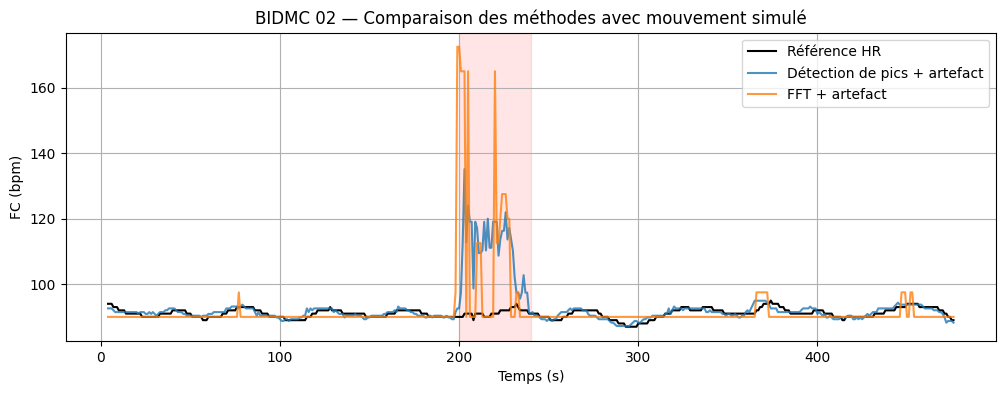

**Conclusion.** Sans artefact, MAE : **0.80 bpm** pour les pics et **1.42 bpm** pour la FFT. Pendant le mouvement : **19.08** et **19.71 bpm** respectivement. Le maximum spectral peut suivre le mouvement au lieu du pouls, puisque leurs bandes de fréquence se recouvrent. Une belle périodicité ne prouve donc pas l'origine cardiaque du signal.

In [6]:
fft_propre = fc_fft(y, FS, tc)
fft_art = fc_fft(y_art, FS, tc)
lignes_fft = []
for nom, valeurs, mouvement in [("Pics, sans artefact", fc, False), ("FFT, sans artefact", fft_propre, False),
                               ("Pics, avec artefact", fc_art, True), ("FFT, avec artefact", fft_art, True)]:
    lignes_fft.append({"Méthode": nom, "MAE globale (bpm)": erreur(valeurs, hr),
        "MAE 200–240 s (bpm)": erreur(valeurs, hr, zone),
        "Disponibilité (%)": 100 * np.isfinite(valeurs).mean()})
table_fft = pd.DataFrame(lignes_fft)
display(table_fft.round(3)); table_fft.to_csv(RESULTATS / "bonus2_fft.csv", index=False)
plt.plot(tc, hr, label="Référence HR", color="black")
plt.plot(tc, fc_art, label="Détection de pics + artefact", alpha=0.8)
plt.plot(tc, fft_art, label="FFT + artefact", alpha=0.8)
plt.axvspan(200, 240, color="red", alpha=0.1)
plt.title("BIDMC 02 — Comparaison des méthodes avec mouvement simulé")
plt.xlabel("Temps (s)"); plt.ylabel("FC (bpm)"); plt.legend(); plt.show()
display(Markdown(f"**Conclusion.** Sans artefact, MAE : **{erreur(fc,hr):.2f} bpm** pour les pics "
                 f"et **{erreur(fft_propre,hr):.2f} bpm** pour la FFT. Pendant le mouvement : "
                 f"**{erreur(fc_art,hr,zone):.2f}** et **{erreur(fft_art,hr,zone):.2f} bpm** respectivement. "
                 "Le maximum spectral peut suivre le mouvement au lieu du pouls, puisque leurs bandes de fréquence se recouvrent. "
                 "Une belle périodicité ne prouve donc pas l'origine cardiaque du signal."))


## Bonus 3 — Un filtre causal, comme sur l'ESP32

On remplace **`sosfiltfilt` par `sosfilt`**, avec les mêmes coefficients. Après exclusion des 8 premières secondes (transitoire de démarrage), on apparie les pics les plus proches à moins de 250 ms ; les doublons sont exclus. Le décalage est signé : **positif = pic causal plus tardif**. Ce décalage de sommet dépend de la morphologie et n'est pas un retard constant à toutes les fréquences.

Un filtre causal ne suffit pas à rendre toute la chaîne temps réel : la fenêtre centrée du TP utilise aussi 4 s de futur. Une comparaison avec une fenêtre portant sur les **8 dernières secondes** est ajoutée et explicitement distinguée.


,Méthode,MAE à partir de 8 s (bpm)
0,"Aller-retour, fenêtre centrée",0.794
1,"Causal, fenêtre centrée",0.794
2,"Causal, 8 dernières secondes",0.454


703 paires ; décalage médian 48.0 ms ; P5/P95 24.0/64.0 ms


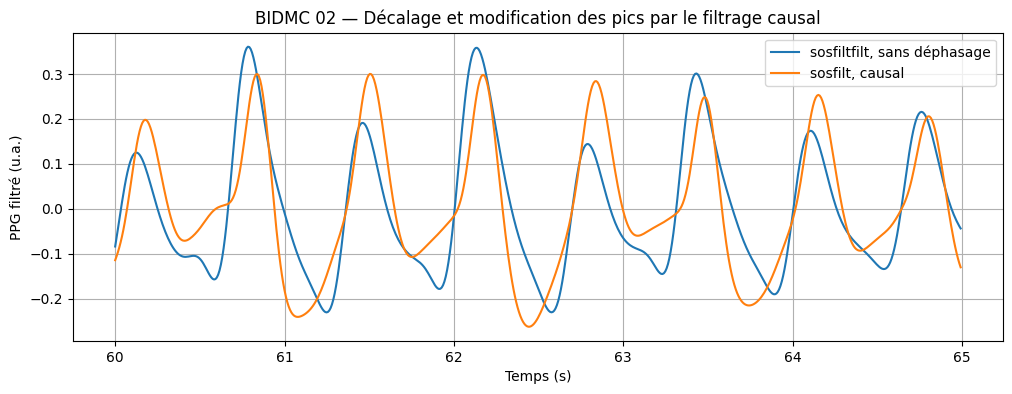

**Conclusion.** Le décalage médian des sommets appariés est de **48 ms**. Il est petit devant une mise à jour toutes les secondes, et un décalage presque commun aux deux pics se compense en grande partie dans leur intervalle. Le lissage sur 8 s retarde aussi la réponse aux changements. Une implémentation embarquée doit encore gérer la détection des pics et les seuils en flux : ce test hors ligne du filtre n'est pas un programme ESP32 complet.

In [7]:
yc, pc, fcc, cvc = chaine(x, FS, tc, causal=True)
p0 = p[(p/FS >= 8) & (p/FS <= t[-1]-8)]
p1 = pc[(pc/FS >= 8) & (pc/FS <= t[-1]-8)]
associations = []
deja = set()
for pic in p0:
    k = int(np.argmin(np.abs(p1-pic)))
    if abs(p1[k]-pic)/FS <= 0.25 and k not in deja:
        associations.append((pic, p1[k])); deja.add(k)
retards = (np.array(associations)[:,1] - np.array(associations)[:,0]) / FS * 1000
# Même fonction, centres reculés de 4 s : intervalles terminant entre tc-8 et tc.
fc_passee, _ = fc_fenetres(pc/FS, tc-4)
valide = tc >= 8
table_causal = pd.DataFrame({"Méthode": ["Aller-retour, fenêtre centrée", "Causal, fenêtre centrée", "Causal, 8 dernières secondes"],
    "MAE à partir de 8 s (bpm)": [erreur(fc,hr,valide), erreur(fcc,hr,valide), erreur(fc_passee,hr,valide)]})
display(table_causal.round(3)); table_causal.to_csv(RESULTATS / "bonus3_causal.csv", index=False)
print(f"{len(retards)} paires ; décalage médian {np.median(retards):.1f} ms ; "
      f"P5/P95 {np.percentile(retards,5):.1f}/{np.percentile(retards,95):.1f} ms")
z = (t>=60)&(t<65)
plt.plot(t[z], y[z], label="sosfiltfilt, sans déphasage")
plt.plot(t[z], yc[z], label="sosfilt, causal")
plt.title("BIDMC 02 — Décalage et modification des pics par le filtrage causal")
plt.xlabel("Temps (s)"); plt.ylabel("PPG filtré (u.a.)"); plt.legend(); plt.show()
display(Markdown(f"**Conclusion.** Le décalage médian des sommets appariés est de **{np.median(retards):.0f} ms**. "
                 "Il est petit devant une mise à jour toutes les secondes, et un décalage presque commun aux deux pics "
                 "se compense en grande partie dans leur intervalle. Le lissage sur 8 s retarde aussi la réponse aux changements. "
                 "Une implémentation embarquée doit encore gérer la détection des pics et les seuils en flux : "
                 "ce test hors ligne du filtre n'est pas un programme ESP32 complet."))


## Bonus 4 — Ajouter un critère de forme

Pour chaque fenêtre de 8 s, on extrait les battements autour des pics, puis on corrèle chacun à la **forme moyenne** de la fenêtre. On demande que la corrélation minimale soit **au moins 0,80**, seuil exploratoire fixé avant la comparaison. La règle demandée est **CV < 0,15 ET FC plausible ET forme suffisante**.

Point logique : ajouter une condition avec **ET** ne peut jamais récupérer une fenêtre déjà rejetée par le CV. On le mesure sur BIDMC 02 et sur un test contrôlé de battements propres mais irrégulièrement espacés. Ce test synthétique illustre la logique ; il ne simule pas une pathologie validée.


,Signal,Règle,Transmission (%),MAE transmise (bpm)
0,BIDMC original,CV et plausibilité,98.309,0.802
1,BIDMC original,"CV, plausibilité et forme",90.698,0.794
2,BIDMC avec artefact,CV et plausibilité,90.063,0.804
3,BIDMC avec artefact,"CV, plausibilité et forme",84.144,0.802


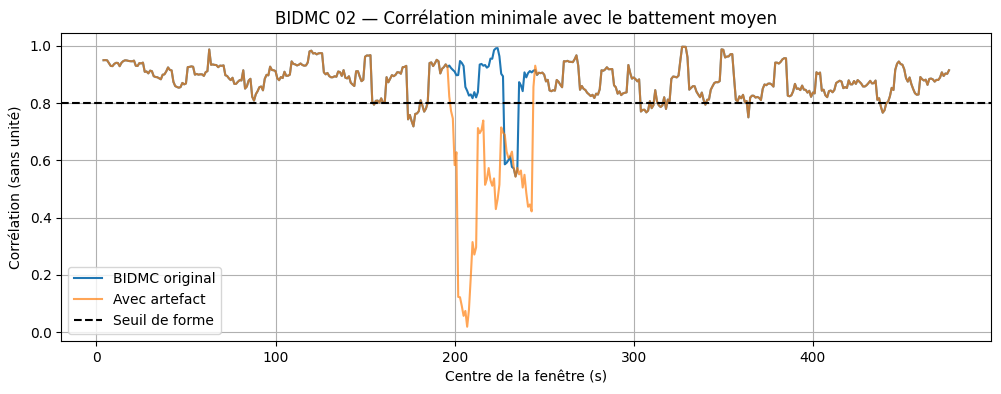

Test SYNTHÉTIQUE irrégulier : CV médian 0.236, forme médiane 0.997, rejet CV 100.0 %, rejet CV+forme 100.0 %


**Conclusion.** Les fenêtres propres mais irrégulières restent rejetées avec la règle ajoutée par ET. La morphologie apporte une information complémentaire mais ne résout pas à elle seule ce problème logique. Distinguer irrégularité cardiaque et bruit demanderait une autre règle validée, et éventuellement l'ECG ou l'accéléromètre. Le seuil de forme de 0,80 n'est pas une validation clinique.

In [8]:
forme = score_forme(y, p, FS, tc)
forme_art = score_forme(y_art, p_art, FS, tc)
lignes_forme = []
for nom, valeurs, variations, score in [("BIDMC original", fc, cv, forme), ("BIDMC avec artefact", fc_art, cv_art, forme_art)]:
    ok_cv = qualite(valeurs, variations)
    ok_forme = ok_cv & (score >= 0.80)
    assert np.all(~ok_forme | ok_cv)
    for regle, accepte in [("CV et plausibilité", ok_cv), ("CV, plausibilité et forme", ok_forme)]:
        lignes_forme.append({"Signal": nom, "Règle": regle, "Transmission (%)": 100*accepte.mean(),
                            "MAE transmise (bpm)": erreur(valeurs,hr,accepte)})
table_forme = pd.DataFrame(lignes_forme)
display(table_forme.round(3)); table_forme.to_csv(RESULTATS / "bonus4_forme.csv", index=False)
plt.plot(tc, forme, label="BIDMC original")
plt.plot(tc, forme_art, label="Avec artefact", alpha=0.7)
plt.axhline(.80, ls="--", color="black", label="Seuil de forme")
plt.title("BIDMC 02 — Corrélation minimale avec le battement moyen")
plt.xlabel("Centre de la fenêtre (s)"); plt.ylabel("Corrélation (sans unité)"); plt.legend(); plt.show()

# Test synthétique explicitement séparé des données réelles.
ts = np.arange(0, 60, 1/FS)
xs = np.zeros_like(ts)
tb = 0.5
index = 0
while tb < 60:
    xs += np.exp(-((ts-tb)/0.055)**2)  # même forme propre à chaque battement
    tb += [0.45, 0.90, 0.65, 0.70][index % 4]
    index += 1
ps, _ = signal.find_peaks(xs, distance=int(FS*60/180), prominence=.5*np.std(xs))
cs = np.arange(4, 56)
hs, cvs = fc_fenetres(ps/FS, cs)
ss = score_forme(xs, ps, FS, cs)
qs = qualite(hs,cvs)
qss = qs & (ss >= .80)
print(f"Test SYNTHÉTIQUE irrégulier : CV médian {np.median(cvs):.3f}, "
      f"forme médiane {np.median(ss):.3f}, rejet CV {100*(~qs).mean():.1f} %, "
      f"rejet CV+forme {100*(~qss).mean():.1f} %")
display(Markdown("**Conclusion.** Les fenêtres propres mais irrégulières restent rejetées avec la règle ajoutée par ET. "
                 "La morphologie apporte une information complémentaire mais ne résout pas à elle seule ce problème logique. "
                 "Distinguer irrégularité cardiaque et bruit demanderait une autre règle validée, et éventuellement l'ECG ou l'accéléromètre. "
                 "Le seuil de forme de 0,80 n'est pas une validation clinique."))


## Bonus 5 — Mouvement réel : PPG-DaLiA

**Périmètre : sujet S1**, environ 2 h 30 d'activités quotidiennes. Ce sujet n'est pas le patient BIDMC 02. Source : UCI PPG-DaLiA, DOI **10.24432/C53890**, licence CC BY 4.0 ; Reiss et al., *Deep PPG*, 2019.

La documentation officielle fournit un PPG au poignet à **64 Hz**, l'accélération à **32 Hz**, les activités à **4 Hz** et une référence ECG sur des fenêtres de **8 s décalées de 2 s**. On respecte cet alignement : centres à 4, 6, 8… secondes. La chaîne du TP est conservée, en adaptant seulement la fréquence d'échantillonnage. Les fenêtres à cheval sur plusieurs activités sont écartées des comparaisons par activité.

L'amplitude de mouvement est la RMS des trois axes après soustraction de leur moyenne locale (unités du fichier synchronisé). Une règle exploratoire CV + accélération utilise le 95e percentile de cette RMS sur les 120 premières secondes disponibles de repos. Ces fenêtres de calibration et leur voisinage chevauchant sont exclus de l'évaluation de cette règle. Ce n'est pas une validation sur des sujets indépendants.


,Activité,Fenêtres de 8 s,FC disponible (%),MAE (bpm),FC transmise CV (%),MAE transmise CV (bpm),Mouvement RMS médian (u. fichier)
0,Assis,347,100.0,3.100,71.470,1.489,0.008
1,Escaliers,140,100.0,23.892,9.286,27.342,0.449
2,Baby-foot,169,100.0,11.760,0.592,6.399,0.465
3,Vélo,203,100.0,4.470,21.182,1.239,0.641
4,Conduite,441,100.0,5.608,19.048,2.631,0.299
5,Déjeuner,1174,100.0,8.647,9.199,2.835,0.249
6,Marche,373,100.0,9.417,2.681,15.954,0.511
7,Travail,591,100.0,3.198,43.824,1.106,0.047


S1 : 153.5 min, 4603 fenêtres ; MAE disponible 8.19 bpm ; disponibilité 99.5 %


,Règle,Fenêtres évaluées,Transmission (%),MAE transmise (bpm)
0,FC disponible,3374,100.00,7.478
1,CV et plausibilité,3374,21.31,2.356
2,"CV, plausibilité et mouvement",3374,19.68,1.780


Seuil RMS exploratoire : 0.46043 ; calibration sur 60 fenêtres de repos


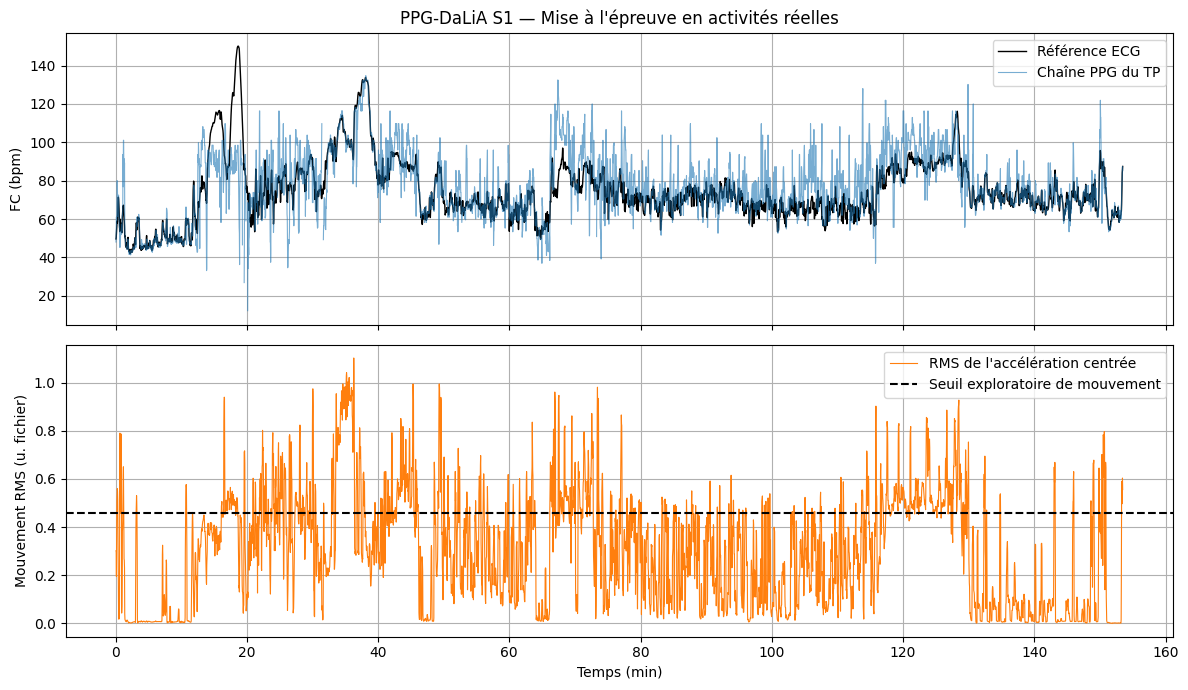

**Conclusion.** La MAE sur les valeurs disponibles de S1 est **8.19 bpm**, contre **0.80 bpm** pour BIDMC 02 au repos. Il s'agit de sujets, capteurs et conditions différents : l'écart ne mesure pas uniquement l'effet du mouvement. L'accéléromètre fournit un indice indépendant du rythme des pics ; la comparaison ci-dessus montre le coût en disponibilité de son utilisation comme motif de rejet. Un seuil calibré sur S1 ne peut pas être généralisé aux 15 sujets sans une évaluation supplémentaire. La chaîne simple du TP n'est pas un algorithme de compensation du mouvement.

In [9]:
# Chargement du vrai sujet S1 ; aucun repli synthétique.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="dtype.*align.*")
    bvp, acc, labels, activites = preparer_dalia(BONUS)
fs_d = 64
centres_d = 4 + 2*np.arange(len(labels))
assert len(labels) == (len(bvp)-8*fs_d)//(2*fs_d)+1
assert len(acc)/32 == len(bvp)/64 == len(activites)/4
yd, pd_d, fd, cvd = chaine(bvp, fs_d, centres_d)
qualite_d = qualite(fd,cvd)
ids, mouvements = [], []
for centre in centres_d:
    debut = centre-4
    a = acc[int(debut*32):int((debut+8)*32)]
    mouvements.append(np.sqrt(np.mean(np.sum((a-a.mean(axis=0))**2, axis=1))))
    act = activites[int(debut*4):int((debut+8)*4)].astype(int)
    ids.append(int(act[0]) if np.all(act==act[0]) else -1)
ids = np.array(ids); mouvements = np.array(mouvements)
noms_activites = {1:"Assis", 2:"Escaliers", 3:"Baby-foot", 4:"Vélo", 5:"Conduite", 6:"Déjeuner", 7:"Marche", 8:"Travail"}
lignes_d = []
for aid, nom in noms_activites.items():
    z = ids == aid
    lignes_d.append({"Activité":nom, "Fenêtres de 8 s":int(z.sum()),
        "FC disponible (%)":100*np.isfinite(fd[z]).mean(),
        "MAE (bpm)":erreur(fd,labels,z),
        "FC transmise CV (%)":100*qualite_d[z].mean(),
        "MAE transmise CV (bpm)":erreur(fd,labels,z & qualite_d),
        "Mouvement RMS médian (u. fichier)":np.median(mouvements[z])})
table_d = pd.DataFrame(lignes_d)
display(table_d.round(3)); table_d.to_csv(RESULTATS / "bonus5_dalia_activites.csv",index=False)
print(f"S1 : {len(bvp)/64/60:.1f} min, {len(labels)} fenêtres ; "
      f"MAE disponible {erreur(fd,labels):.2f} bpm ; disponibilité {100*np.isfinite(fd).mean():.1f} %")

repos = np.flatnonzero(ids==1)
cal = repos[centres_d[repos] < centres_d[repos[0]]+120]
seuil_acc = np.percentile(mouvements[cal],95)
evaluation = (ids>=1) & ((centres_d < centres_d[cal[0]]-8) | (centres_d > centres_d[cal[-1]]+8))
q_acc = qualite_d & (mouvements <= seuil_acc)
table_acc = pd.DataFrame([{"Règle":nom, "Fenêtres évaluées":int(evaluation.sum()),
    "Transmission (%)":100*ok[evaluation].mean(), "MAE transmise (bpm)":erreur(fd,labels,evaluation & ok)}
    for nom,ok in [("FC disponible",np.isfinite(fd)),("CV et plausibilité",qualite_d),("CV, plausibilité et mouvement",q_acc)]])
display(table_acc.round(3)); table_acc.to_csv(RESULTATS / "bonus5_dalia_accelerometre.csv",index=False)
print(f"Seuil RMS exploratoire : {seuil_acc:.5f} ; calibration sur {len(cal)} fenêtres de repos")

fig, axes = plt.subplots(2,1,figsize=(12,7),sharex=True)
axes[0].plot(centres_d/60,labels,label="Référence ECG",color="black",lw=1)
axes[0].plot(centres_d/60,fd,label="Chaîne PPG du TP",alpha=.6,lw=.8)
axes[0].set(title="PPG-DaLiA S1 — Mise à l'épreuve en activités réelles",ylabel="FC (bpm)")
axes[0].legend()
axes[1].plot(centres_d/60,mouvements,label="RMS de l'accélération centrée",color="tab:orange",lw=.8)
axes[1].axhline(seuil_acc,ls="--",color="black",label="Seuil exploratoire de mouvement")
axes[1].set(xlabel="Temps (min)",ylabel="Mouvement RMS (u. fichier)");axes[1].legend()
plt.tight_layout();plt.show()
display(Markdown(f"**Conclusion.** La MAE sur les valeurs disponibles de S1 est **{erreur(fd,labels):.2f} bpm**, "
                 f"contre **{erreur(fc,hr):.2f} bpm** pour BIDMC 02 au repos. "
                 "Il s'agit de sujets, capteurs et conditions différents : l'écart ne mesure pas uniquement l'effet du mouvement. "
                 "L'accéléromètre fournit un indice indépendant du rythme des pics ; la comparaison ci-dessus montre le coût "
                 "en disponibilité de son utilisation comme motif de rejet. Un seuil calibré sur S1 ne peut pas être généralisé "
                 "aux 15 sujets sans une évaluation supplémentaire. La chaîne simple du TP n'est pas un algorithme de compensation du mouvement."))


## Bonus 6 — Les 53 enregistrements BIDMC

On applique **les mêmes réglages** à tous les patients : 0,5–5 Hz, ordre 4, FC_MAX 180, proéminence 0,5, fenêtres de 8 s et seuil CV 0,15. Chaque paire de CSV est vérifiée par SHA-256 avec le manifeste officiel. **Aucun repli synthétique** n'est autorisé ici.

La MAE est calculée par enregistrement sur les secondes où la référence HR est présente et la fenêtre complète. On conserve aussi la disponibilité et la MAE après rejet : une faible erreur obtenue en supprimant beaucoup de mesures ne suffit pas. La moyenne des MAE par patient donne le même poids à chaque patient.


10/53 patients analysés


20/53 patients analysés


30/53 patients analysés


40/53 patients analysés


50/53 patients analysés
53/53 patients analysés


,Patient,Secondes de référence,FC référence moyenne (bpm),MAE brute (bpm),MAE filtrée (bpm),Pire écart (bpm),FC disponible (%),FC transmise qualité (%),MAE transmise (bpm),Pics détectés
0,01,473,91.311,0.787,1.462,63.703,100.000,94.503,0.537,716
1,02,473,91.066,0.775,0.799,3.937,100.000,98.309,0.802,727
2,03,473,76.645,1.020,1.024,15.469,100.000,86.681,1.029,611
3,04,473,92.455,0.968,1.817,77.352,99.577,75.476,0.689,706
4,05,473,98.205,0.886,1.837,69.703,99.789,93.869,0.742,766
5,06,473,81.839,0.633,0.619,9.478,100.000,100.000,0.619,654
6,07,473,90.099,0.404,0.399,0.820,100.000,100.000,0.399,722
7,08,473,99.947,0.499,0.501,3.316,100.000,100.000,0.501,798
8,09,473,76.744,0.504,0.482,4.469,100.000,100.000,0.482,614
9,10,473,82.110,1.378,1.302,23.441,100.000,86.681,0.978,652


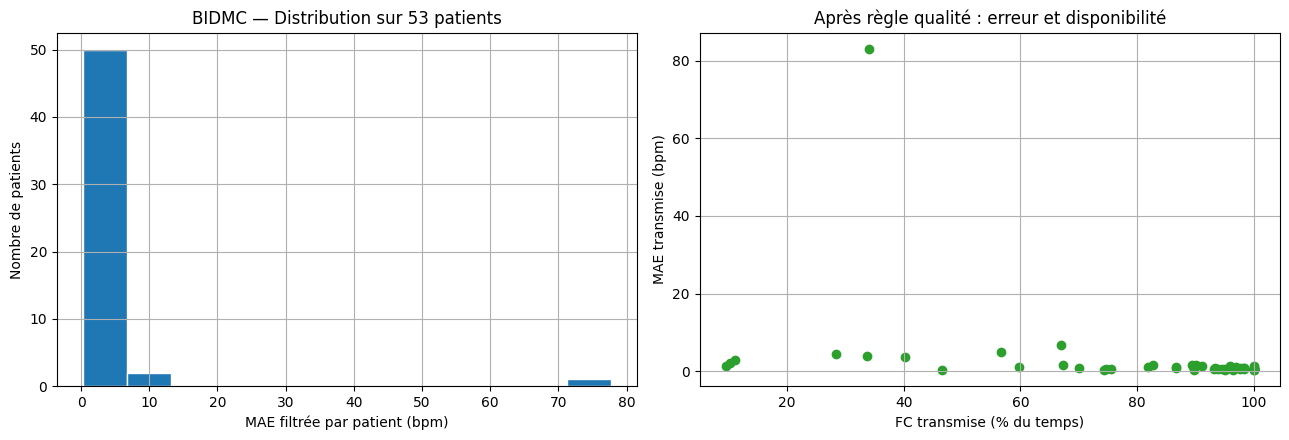

,Patient,Secondes de référence,FC référence moyenne (bpm),MAE brute (bpm),MAE filtrée (bpm),Pire écart (bpm),FC disponible (%),FC transmise qualité (%),MAE transmise (bpm),Pics détectés
46,47,473,83.658,75.744,77.706,87.455,100.0,34.038,82.991,1220
40,41,473,79.175,9.553,8.831,56.579,100.0,40.169,3.836,652
44,45,473,61.163,6.475,6.786,23.381,100.0,67.019,6.729,484
39,40,473,110.444,7.126,6.189,70.677,100.0,46.512,0.434,760
23,24,473,96.526,5.081,5.222,18.773,100.0,56.660,5.050,754


**Résultat global.** MAE filtrée médiane : **1.24 bpm** ; moyenne des 53 MAE : **3.23 bpm** ; maximum : **77.71 bpm**. Les fenêtres se chevauchent et ne constituent pas des observations indépendantes ; aucune conclusion de validation clinique n'est tirée de cette distribution.

In [10]:
lignes_cohorte = []
details = {}
for numero in range(1,54):
    s,n = charger_bidmc(numero,RACINE,BONUS)
    xb = s["PLETH"].to_numpy(float)
    tb = np.arange(len(xb))/125
    r = n[["Time [s]","HR"]].dropna()
    r = r[(r["Time [s]"]>=4)&(r["Time [s]"]<=tb[-1]-4)]
    it = r["Time [s]"].to_numpy(float); href = r.HR.to_numpy(float)
    yf,pf,hf,vf = chaine(xb,125,it)
    _,_,hb,_ = chaine(xb,125,it,filtrer=False)
    q = qualite(hf,vf)
    valide = np.isfinite(hf)&np.isfinite(href)
    erreurs = np.abs(hf-href)
    lignes_cohorte.append({"Patient":f"{numero:02d}","Secondes de référence":len(it),
        "FC référence moyenne (bpm)":np.mean(href),"MAE brute (bpm)":erreur(hb,href),
        "MAE filtrée (bpm)":erreur(hf,href),"Pire écart (bpm)":np.max(erreurs[valide]),
        "FC disponible (%)":100*valide.mean(),"FC transmise qualité (%)":100*q.mean(),
        "MAE transmise (bpm)":erreur(hf,href,q),"Pics détectés":len(pf)})
    details[numero] = (s,n,tb,yf,pf,it,href,hf,vf)
    if numero%10==0 or numero==53: print(f"{numero}/53 patients analysés")
cohorte = pd.DataFrame(lignes_cohorte)
assert len(cohorte)==53 and cohorte.Patient.nunique()==53
cohorte.to_csv(RESULTATS / "bonus6_53_patients.csv",index=False)
display(cohorte.round(3))
fig, axes = plt.subplots(1,2,figsize=(13,4.5))
axes[0].hist(cohorte["MAE filtrée (bpm)"],bins=12,color="tab:blue",edgecolor="white")
axes[0].set(title="BIDMC — Distribution sur 53 patients",xlabel="MAE filtrée par patient (bpm)",ylabel="Nombre de patients")
axes[1].scatter(cohorte["FC transmise qualité (%)"],cohorte["MAE transmise (bpm)"],color="tab:green")
axes[1].set(title="Après règle qualité : erreur et disponibilité",xlabel="FC transmise (% du temps)",ylabel="MAE transmise (bpm)")
plt.tight_layout();plt.show()
classement = cohorte.sort_values("MAE filtrée (bpm)",ascending=False)
display(classement.head(5).round(3))
display(Markdown(f"**Résultat global.** MAE filtrée médiane : **{cohorte['MAE filtrée (bpm)'].median():.2f} bpm** ; "
                 f"moyenne des 53 MAE : **{cohorte['MAE filtrée (bpm)'].mean():.2f} bpm** ; "
                 f"maximum : **{cohorte['MAE filtrée (bpm)'].max():.2f} bpm**. "
                 "Les fenêtres se chevauchent et ne constituent pas des observations indépendantes ; "
                 "aucune conclusion de validation clinique n'est tirée de cette distribution."))


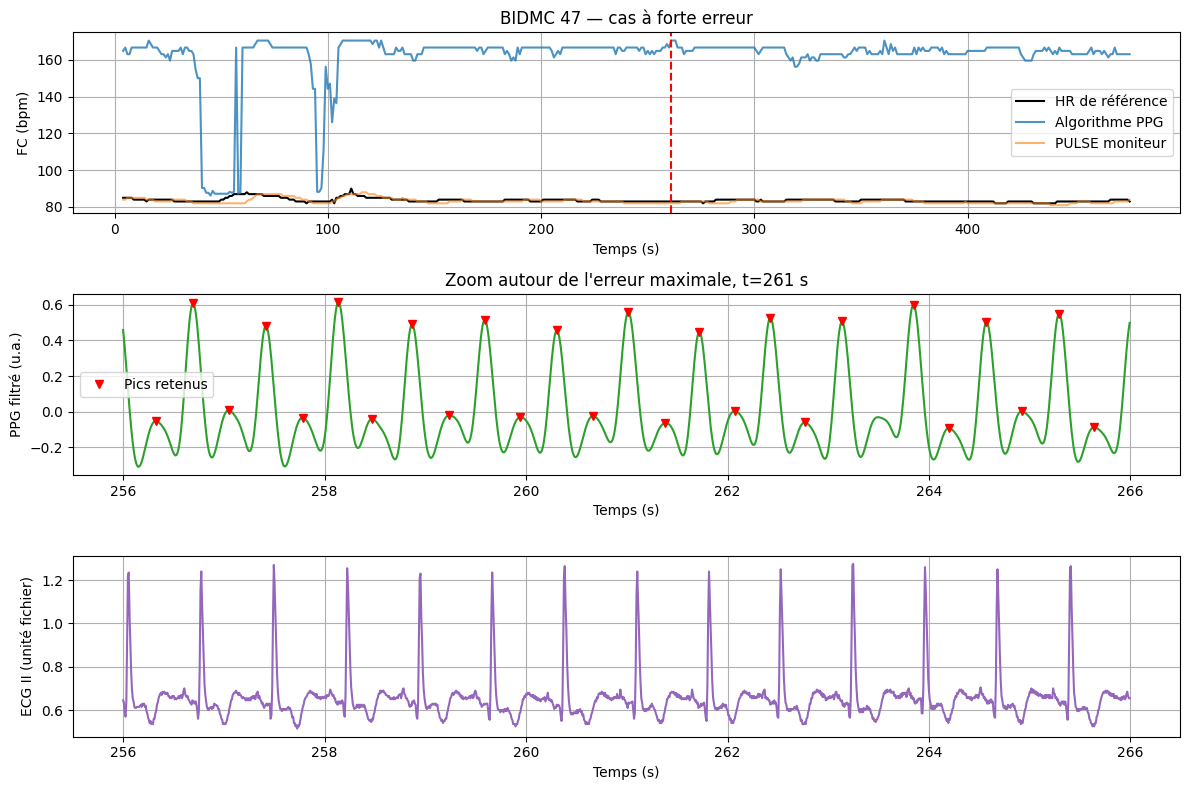

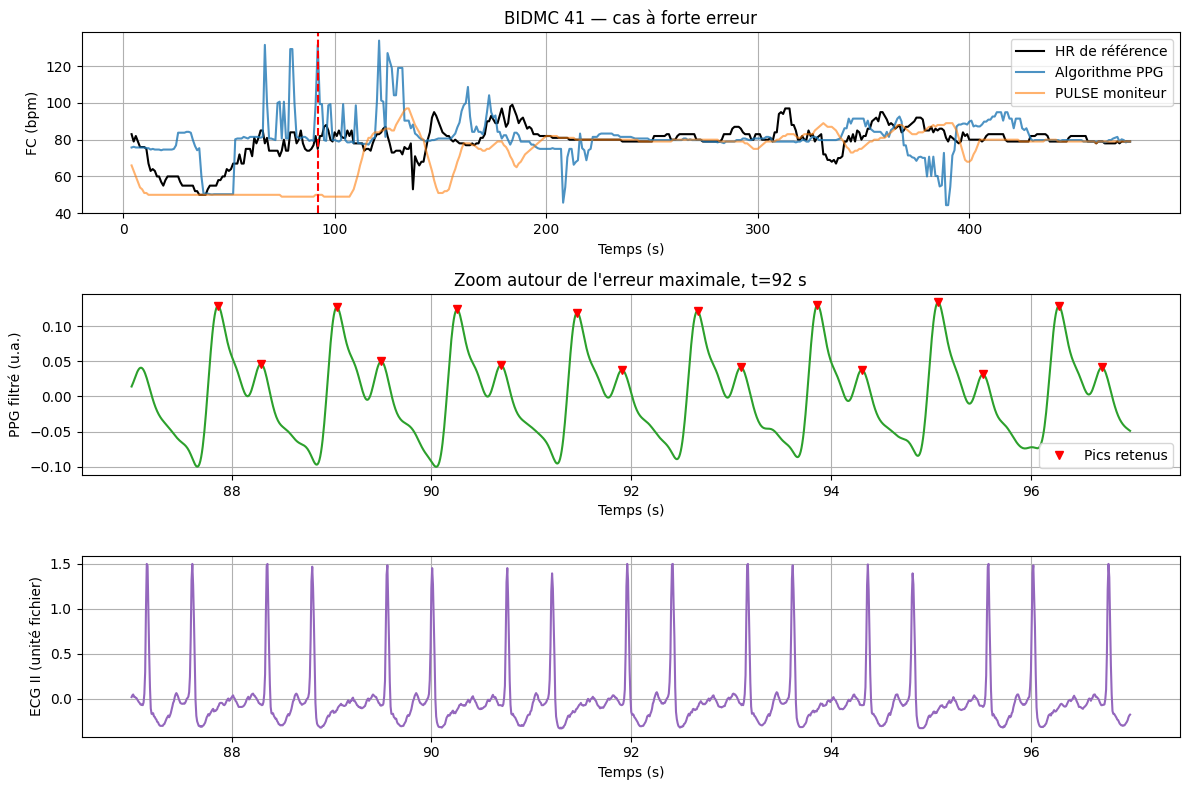

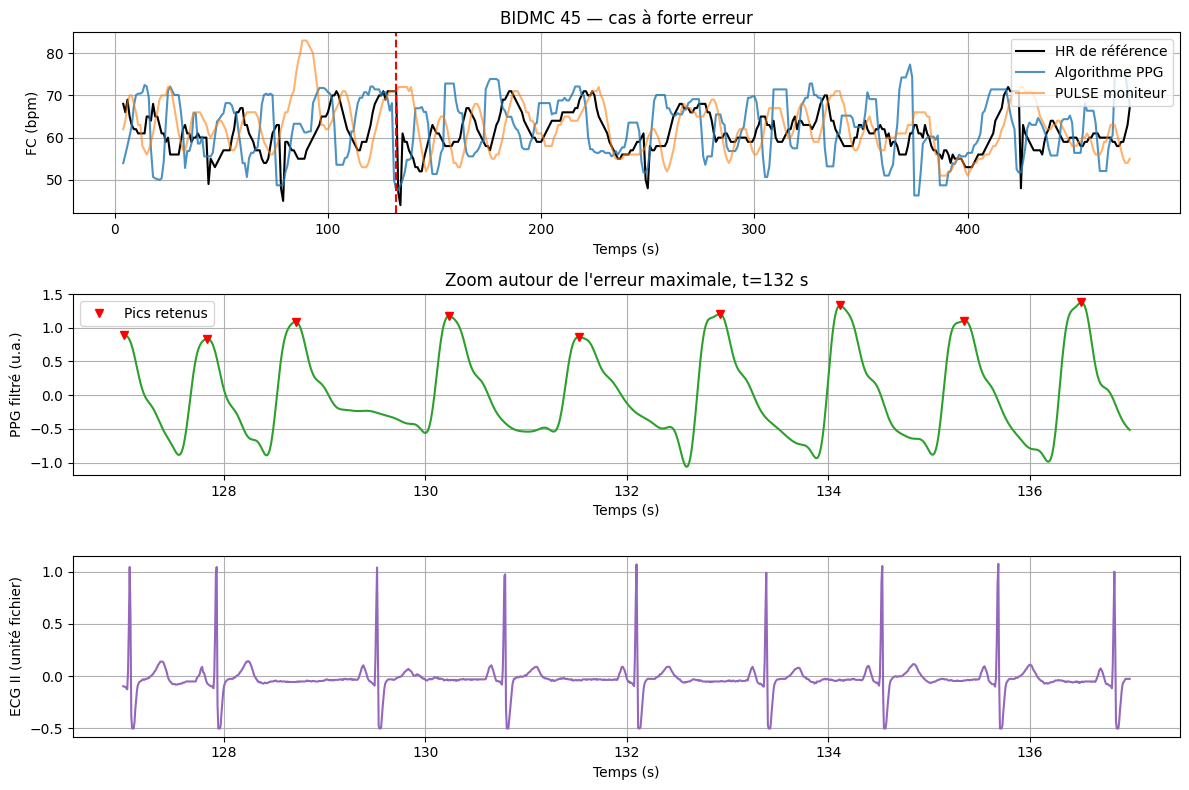

,Patient,Instant inspecté (s),HR (bpm),FC estimée (bpm),PULSE (bpm),Ratio FC estimée / HR,CV,MAE PULSE / HR (bpm)
0,47,261.0,83.0,170.455,82.0,2.054,0.201,0.831
1,41,92.0,75.0,131.579,50.0,1.754,0.269,9.190
2,45,132.0,71.0,47.619,71.0,0.671,0.158,4.755


In [11]:
# Inspection des trois patients ayant la MAE la plus élevée.
# Les fenêtres sont choisies par l'erreur maximale pour comprendre un échec,
# pas pour fournir une estimation représentative de la performance.
diagnostics = []
for identifiant in classement.head(3).Patient:
    numero = int(identifiant)
    s,n,tb,yf,pf,it,href,hf,vf = details[numero]
    k = int(np.nanargmax(np.abs(hf-href)))
    centre = it[k]
    z = (tb>=max(0,centre-5))&(tb<centre+5)
    zp = (pf/125>=max(0,centre-5))&(pf/125<centre+5)
    pulse = n.set_index("Time [s]").PULSE.reindex(it).to_numpy(float)
    ecg_col = next((c for c in ["II","V","AVR"] if c in s.columns),None)
    fig, axes = plt.subplots(3,1,figsize=(12,8))
    axes[0].plot(it,href,label="HR de référence",color="black")
    axes[0].plot(it,hf,label="Algorithme PPG",alpha=.8)
    axes[0].plot(it,pulse,label="PULSE moniteur",alpha=.6)
    axes[0].axvline(centre,color="red",ls="--")
    axes[0].set(title=f"BIDMC {numero:02d} — cas à forte erreur",xlabel="Temps (s)",ylabel="FC (bpm)");axes[0].legend()
    axes[1].plot(tb[z],yf[z],color="tab:green")
    axes[1].plot(pf[zp]/125,yf[pf[zp]],"rv",label="Pics retenus")
    axes[1].set(title=f"Zoom autour de l'erreur maximale, t={centre:g} s",xlabel="Temps (s)",ylabel="PPG filtré (u.a.)");axes[1].legend()
    if ecg_col:
        axes[2].plot(tb[z],s[ecg_col].to_numpy()[z],color="tab:purple")
    axes[2].set(xlabel="Temps (s)",ylabel=f"ECG {ecg_col} (unité fichier)")
    plt.tight_layout();plt.show()
    diagnostics.append({"Patient":numero,"Instant inspecté (s)":centre,
        "HR (bpm)":href[k],"FC estimée (bpm)":hf[k],"PULSE (bpm)":pulse[k],
        "Ratio FC estimée / HR":hf[k]/href[k],"CV":vf[k],
        "MAE PULSE / HR (bpm)":erreur(pulse,href)})
diagnostic_table = pd.DataFrame(diagnostics)
display(diagnostic_table.round(3))
diagnostic_table.to_csv(RESULTATS / "bonus6_cas_difficiles.csv",index=False)


### Interprétation des cas difficiles

- **BIDMC 47 — MAE 77,71 bpm.** Le zoom montre deux pics retenus par cycle, y compris une bosse secondaire. La FC estimée est alors proche du double de HR : 170,45 contre 83 bpm à 261 s. PULSE reste proche de HR (MAE 0,83 bpm). Des faux pics peuvent être très réguliers : la règle qualité laisse passer 34,0 % des secondes et leur MAE atteint 82,99 bpm. Le CV et la plausibilité ne garantissent donc pas la justesse.
- **BIDMC 41 — MAE 8,83 bpm.** Vers 92 s, les triangles montrent également des bosses secondaires prises comme battements. Les estimations changent fortement et PULSE diverge aussi de HR dans certains passages. Cela illustre la sensibilité des seuils fixes à la forme du signal ; la forme de l'ECG est atypique à certains instants, sans qu'on puisse en déduire ici un diagnostic.
- **BIDMC 45 — MAE 6,79 bpm.** Les intervalles entre pics varient dans le segment inspecté ; on n'observe pas le double comptage systématique du patient 47. À 132 s, la médiane des intervalles dans la fenêtre donne 47,62 bpm alors que HR vaut 71 bpm. La fenêtre de 8 s, le choix médiane/moyenne et la temporalité du calcul du moniteur peuvent contribuer à ces écarts. C'est une explication compatible avec les courbes, pas une cause démontrée de tous les écarts.

**Conclusion :** les réglages du groupe 2 ne sont pas universels. La régularité des pics n'est pas une preuve de leur origine cardiaque, et un faible taux de transmission doit être lu avec l'erreur des valeurs conservées.


## Sources et limites

- **Sujet du TP** : Nicolas Laurio, Digi5, module 2, TP M2-1, version étudiants du 9 octobre 2026. Le notebook principal conserve les 43 cellules et le code fourni ; ce fichier contient uniquement les extensions.
- **BIDMC** : Pimentel et al., *BIDMC PPG and Respiration Dataset*, v1.0.0, [PhysioNet](https://physionet.org/content/bidmc/1.0.0/), DOI [10.13026/C2208R](https://doi.org/10.13026/C2208R), ODC-BY 1.0. Voir également Pimentel et al., *Toward a Robust Estimation of Respiratory Rate From Pulse Oximeters*, IEEE TBME 64(8), 2017, DOI 10.1109/TBME.2016.2613124 ; Goldberger et al., *PhysioBank, PhysioToolkit, and PhysioNet*, Circulation, 2000.
- **PPG-DaLiA** : Reiss, Indlekofer et Schmidt (2019), [UCI](https://archive.ics.uci.edu/dataset/495/ppg+dalia), DOI [10.24432/C53890](https://doi.org/10.24432/C53890), CC BY 4.0 ; Reiss et al., *Deep PPG*, Sensors 19(14), 2019. Le fichier `PPG_FieldStudy_readme.pdf` décrit l'alignement 8 s / 2 s et les fréquences des capteurs.
- **SciPy** : documentation de [sosfilt](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.sosfilt.html), [sosfiltfilt](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.sosfiltfilt.html) et [find_peaks](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html).

Il s'agit d'expériences pédagogiques hors ligne. Les seuils de qualité ne distinguent pas systématiquement un artefact d'un véritable rythme irrégulier. Les résultats de S1 ne représentent pas toute la population PPG-DaLiA.


In [12]:
# Traces de reproductibilité des calculs, sans les données brutes.
import platform, scipy, matplotlib
versions = {"Python":platform.python_version(),"numpy":np.__version__,"pandas":pd.__version__,
            "scipy":scipy.__version__,"matplotlib":matplotlib.__version__}
(RESULTATS / "versions.json").write_text(json.dumps(versions,indent=2),encoding="utf-8")
print("Versions :",versions)
print("Six bonus exécutés ; tableaux enregistrés dans",RESULTATS)


Versions : {'Python': '3.14.0', 'numpy': '2.4.2', 'pandas': '2.3.3', 'scipy': '1.17.1', 'matplotlib': '3.10.8'}
Six bonus exécutés ; tableaux enregistrés dans E:\TP Iot\analyses\m2_tp1\bonus\resultats
